In [2]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
import csv

In [5]:
# Hauptverzeichnis mit den Unterordnern
main_folder = "../data/NZZ_original"

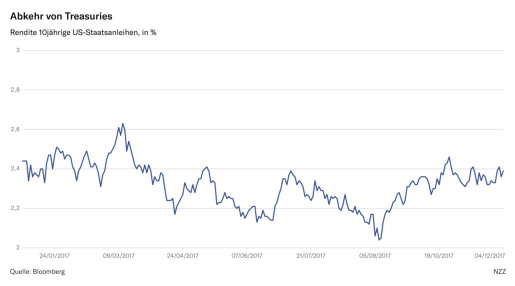

0062e0b6b75d81b20a18a5ab938ada72
Line


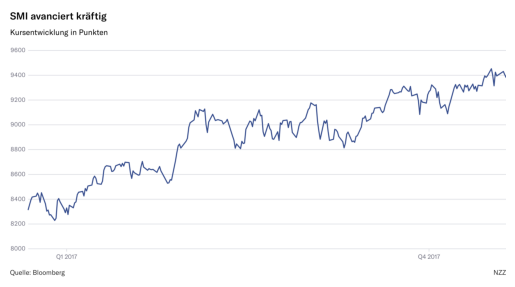

006f6723bd41797d2bb1e3f65444757f
Line


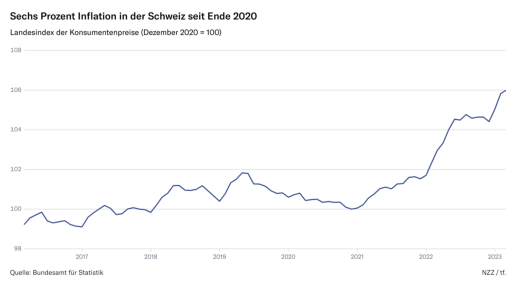

008c17a9b222ca9583df638fc9dbe593
Line


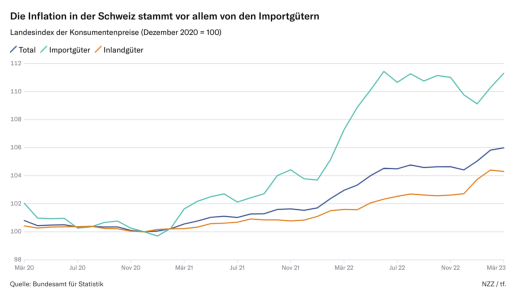

008c17a9b222ca9583df638fc9de316c
Line


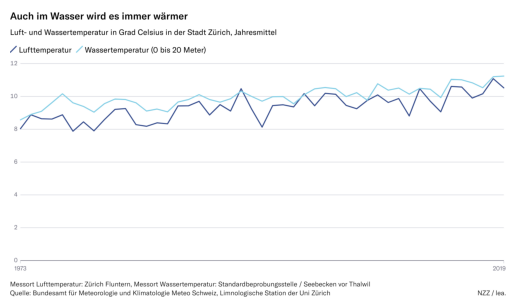

0099651643916eeda249aae35ad10f57
Line


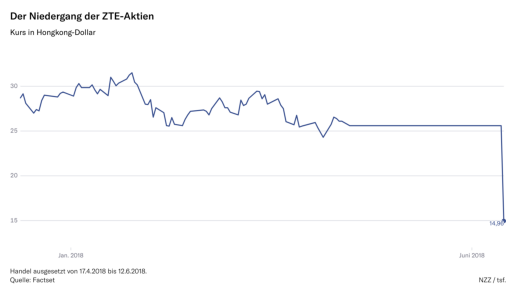

009b187b6b1fe7ca85fcde3801554734
Line


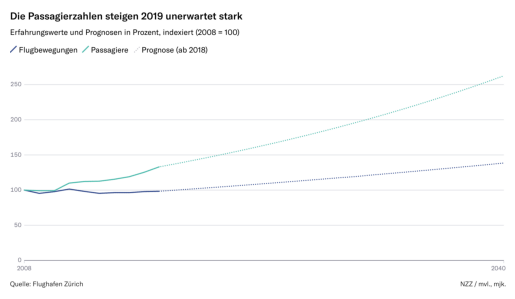

009b187b6b1fe7ca85fcde3801e0c555
Line


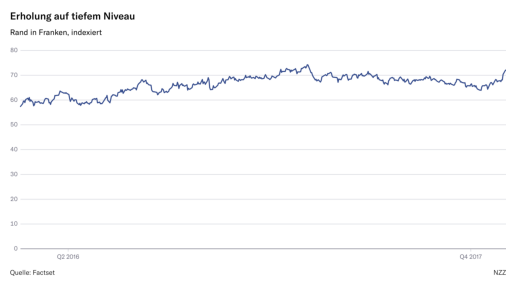

00aec7859796c11ec7cafabb98300540
Line


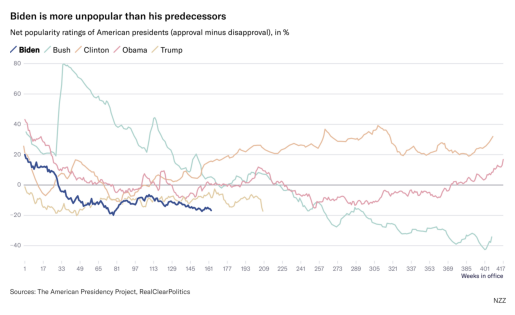

010aa6a0bdfe0194f6ac81b94f4a7cc6
Line


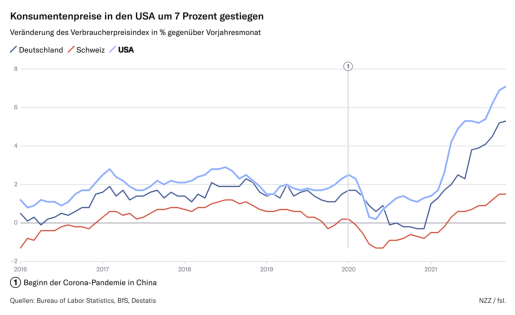

014e6bf3927ddaf505c8053e37c8b688
Line


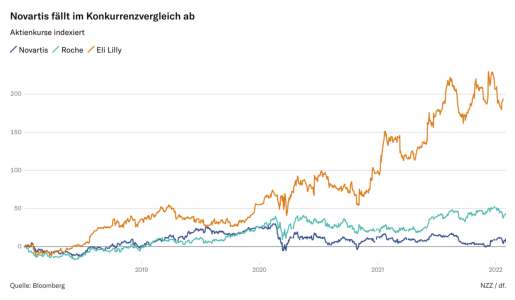

014e6bf3927ddaf505c8053e37cd551d
Line


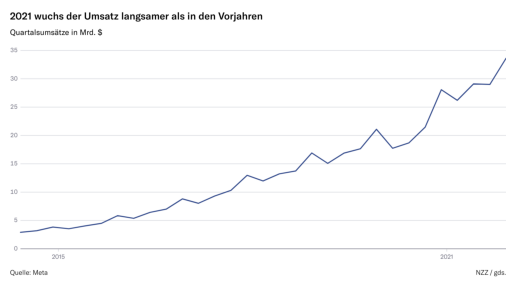

014e6bf3927ddaf505c8053e37d9e275
Line


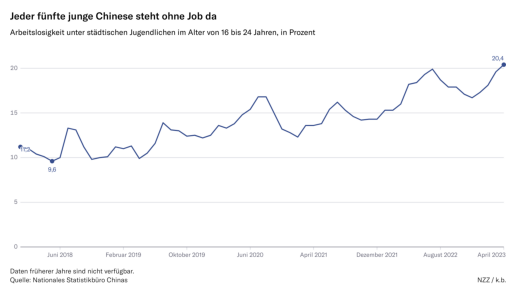

0154a0854ad542755c62796906361086
Line


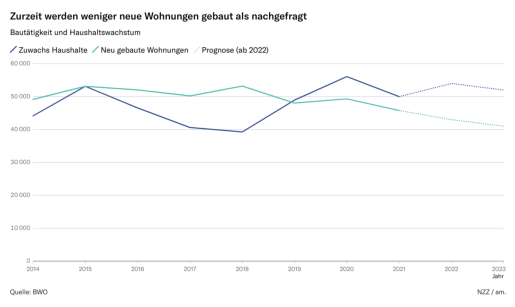

0154a0854ad542755c627969069c0b24
Line


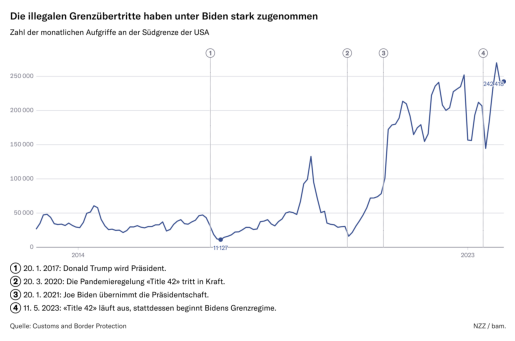

0154a0854ad542755c62796906aadb08
Line


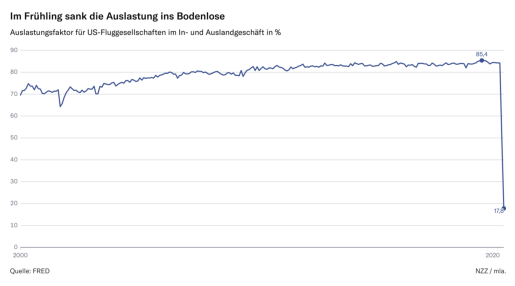

015b1d1184288f807143043e2decb8b3
Line


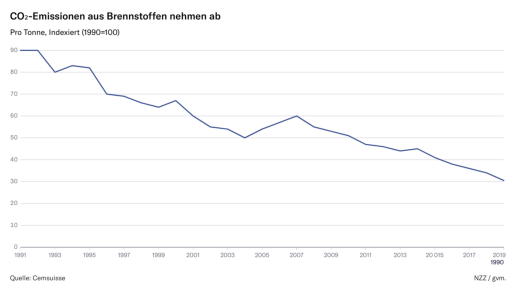

016b459adf53c4e44c03cc7e7078bb83
Line


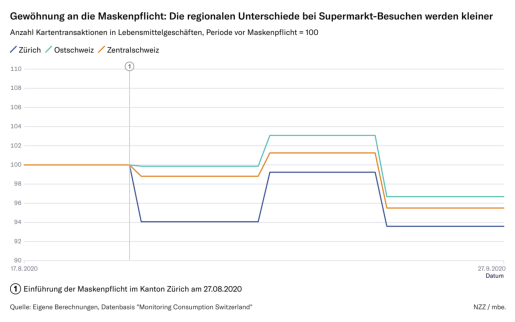

016b459adf53c4e44c03cc7e70ef0c6a
Line


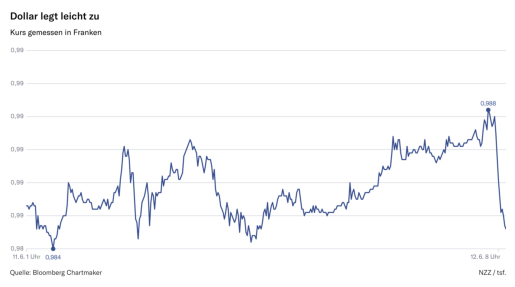

0184a9d83b63d38b3034a63ffa296f09
Line


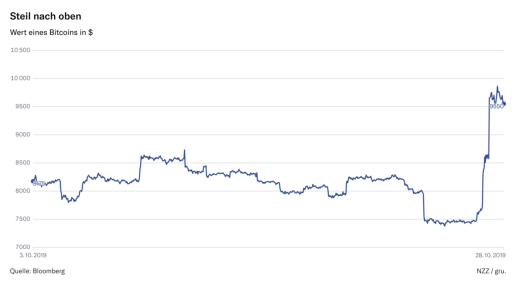

01c2ff365bbb7d826377798d5edc4a33
Line


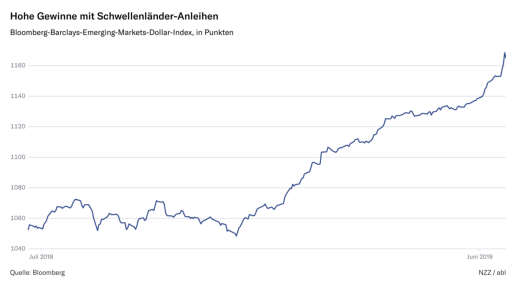

01c8403779c54eaa3618b44952ba9a56
Line


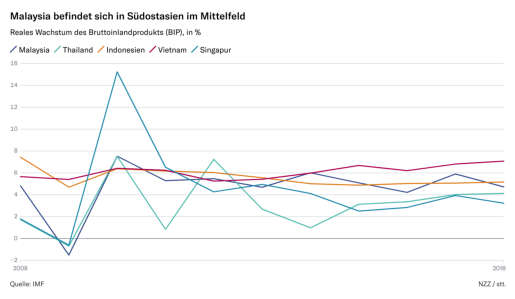

01c8403779c54eaa3618b44952e6d395
Line


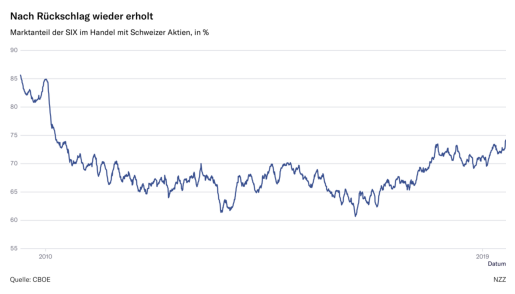

01c8403779c54eaa3618b44952e7fa5f
Line


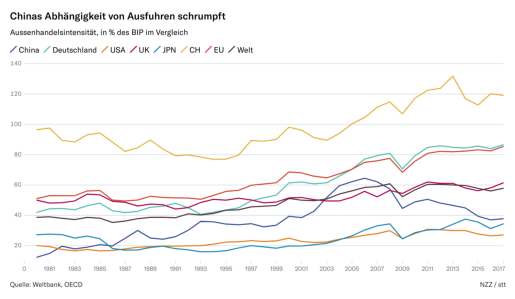

01c8403779c54eaa3618b44952e9f888
Line


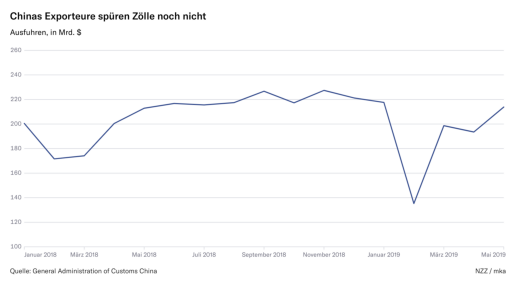

01c8403779c54eaa3618b44952eb2d81
Line


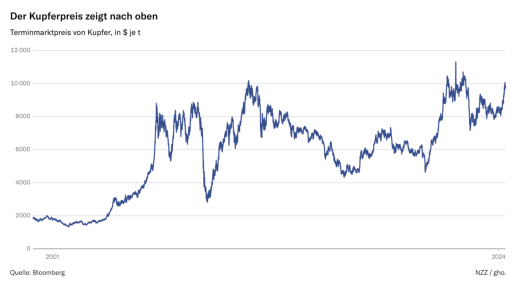

01da15f0f6a6396873566efb701f3887
Line


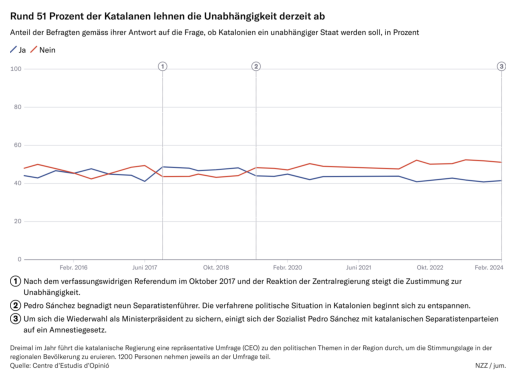

01da15f0f6a6396873566efb70ac7f0d
Line


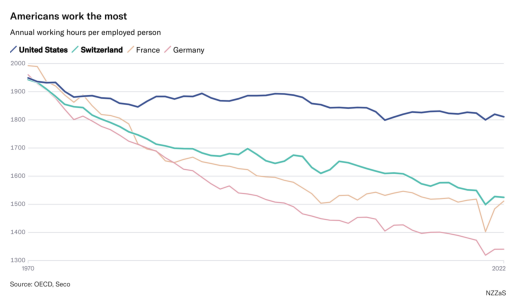

01da15f0f6a6396873566efb70be9d31
Line


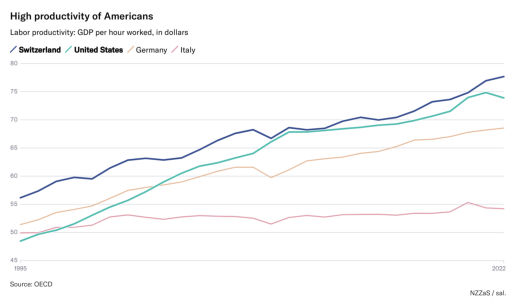

01da15f0f6a6396873566efb70bec404
Line


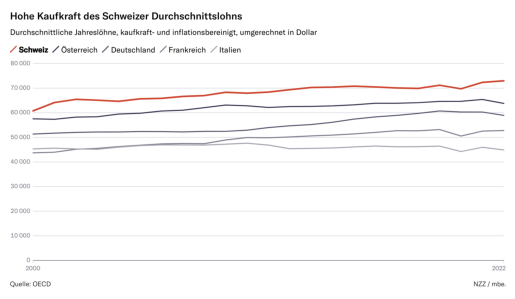

01da15f0f6a6396873566efb70cab5e3
Line


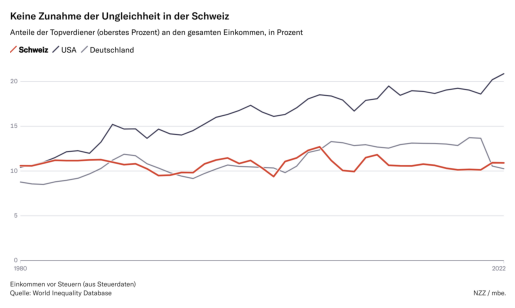

01da15f0f6a6396873566efb70ce21d4
Line


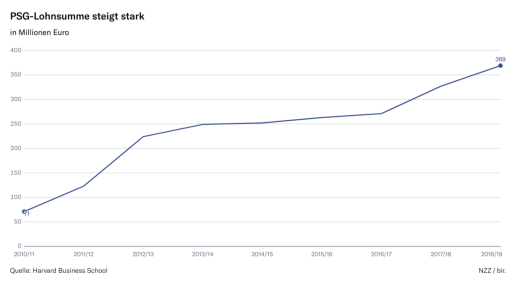

020a5674c151c5184ffc8be26a43b967
Line


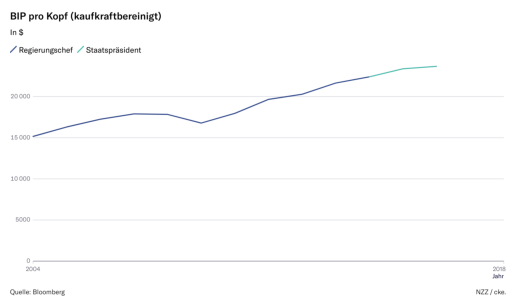

022a672b3f9fa2b1be4ea3c48ad72ca1
Line


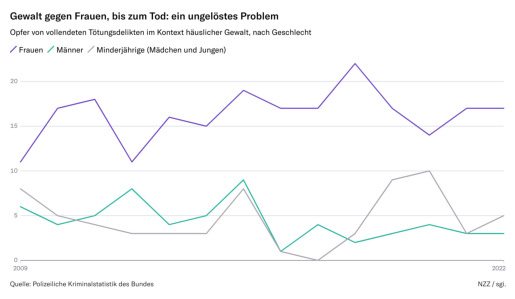

0313da61de86779a1c0b46f5718df868
Line


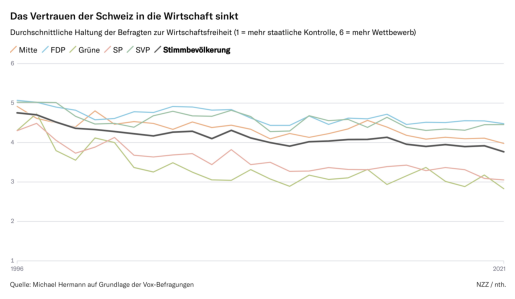

0313da61de86779a1c0b46f571911ad6
Line


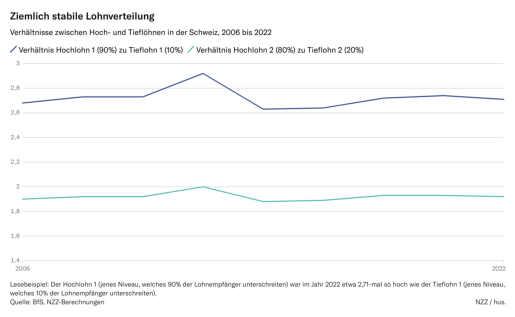

03f2af7351af180c2844811ac231b007
Line


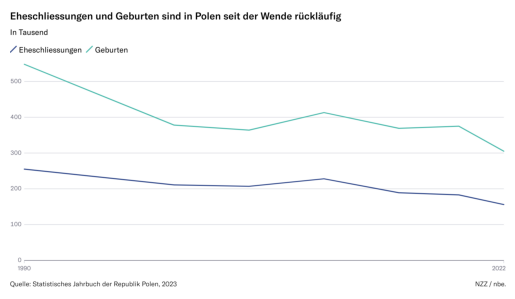

07d00172c0f2b9dd3facaed88507ce79
Line


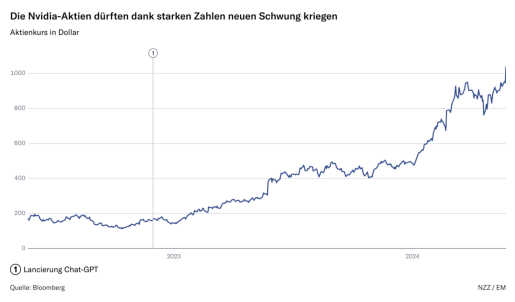

07d00172c0f2b9dd3facaed88599fe8e
Line


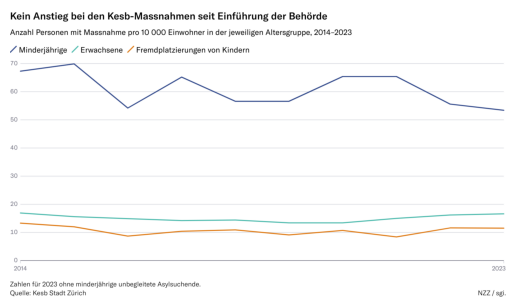

0819c8effbf081938ef522a369004eb7
Line


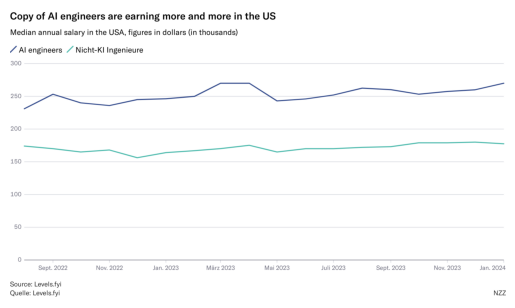

0819c8effbf081938ef522a36909fa85
Line


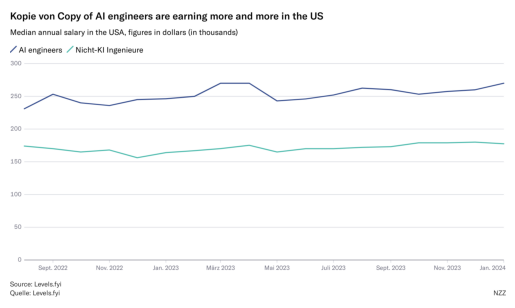

0819c8effbf081938ef522a3690a0ae8
Line


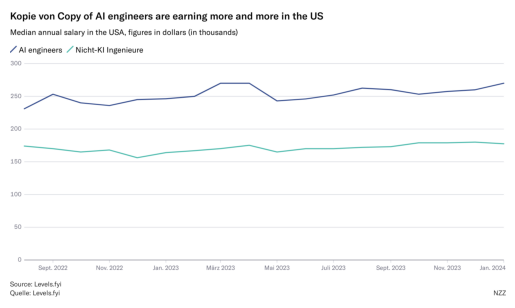

0819c8effbf081938ef522a3690a5120
Line


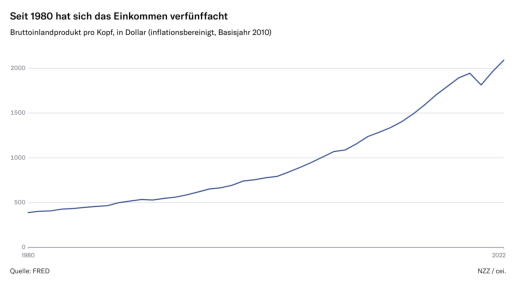

0819c8effbf081938ef522a3690b8545
Line


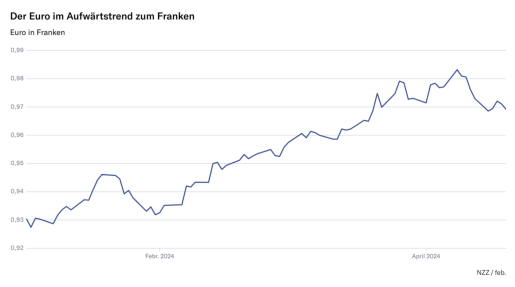

0819c8effbf081938ef522a3690dfc58
Line


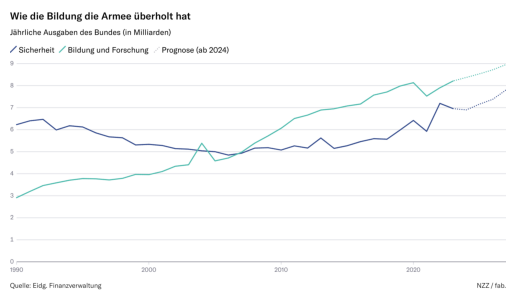

0819c8effbf081938ef522a3691e688b
Line


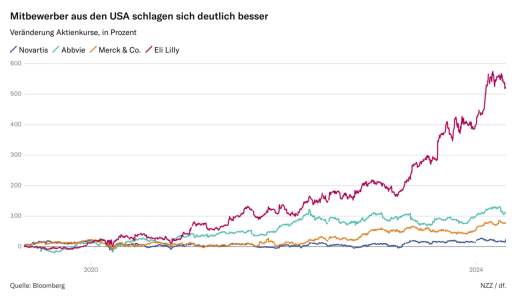

0819c8effbf081938ef522a36926f6f6
Line


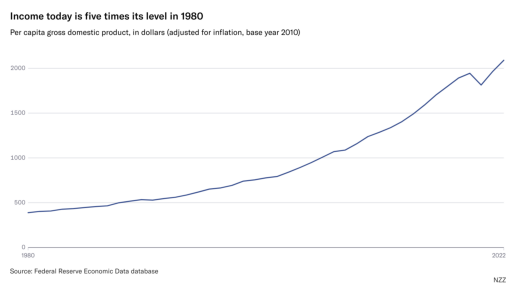

0819c8effbf081938ef522a3692f9a12
Line


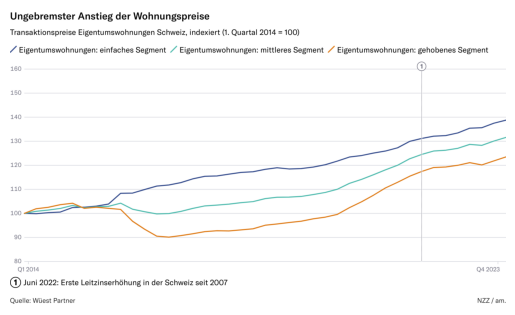

0819c8effbf081938ef522a369393b04
Line


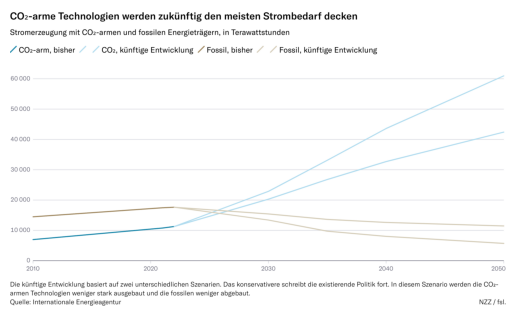

0819c8effbf081938ef522a36942874a
Line


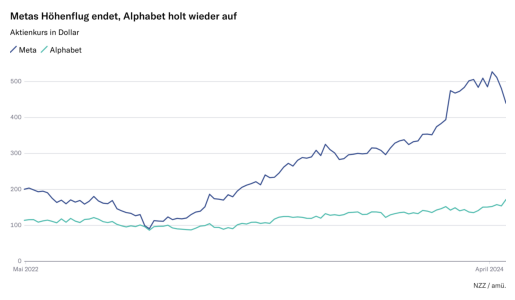

0819c8effbf081938ef522a369439be7
Line


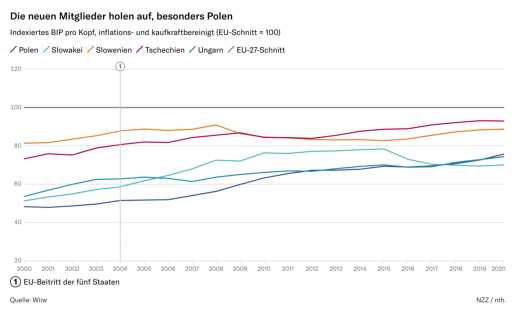

0819c8effbf081938ef522a3694515fb
Line


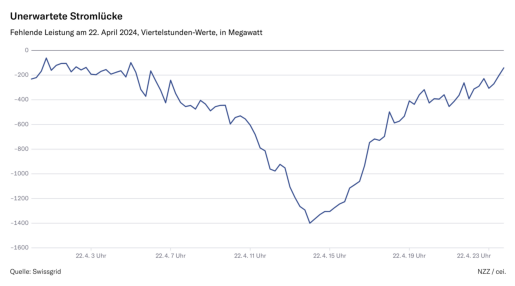

0819c8effbf081938ef522a369492b8e
Line


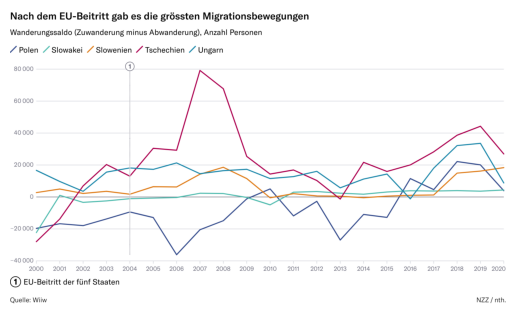

0819c8effbf081938ef522a3695b1194
Line


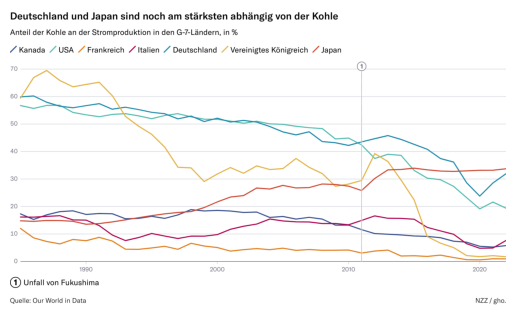

0819c8effbf081938ef522a3697df98f
Line


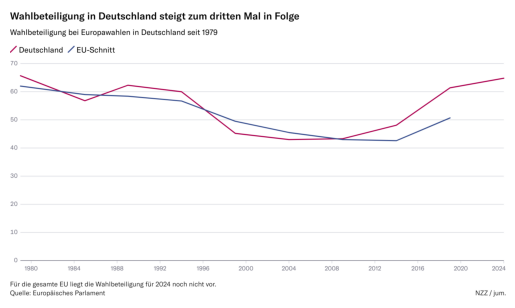

08e996c76bf1a7d4bec453e674564fde
Line


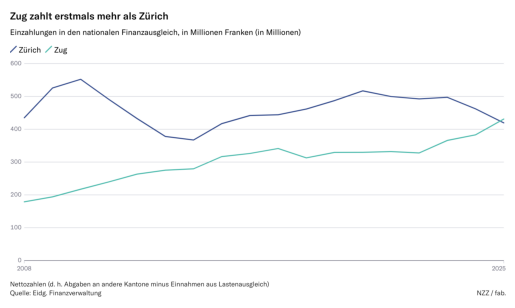

08e996c76bf1a7d4bec453e674c29e14
Line


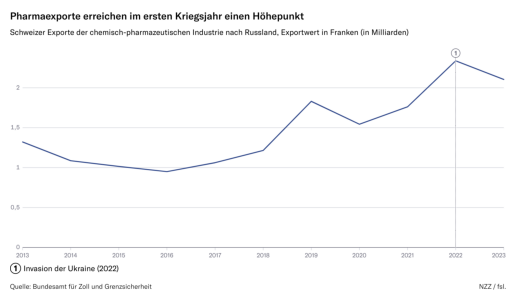

08e996c76bf1a7d4bec453e674cb145c
Line


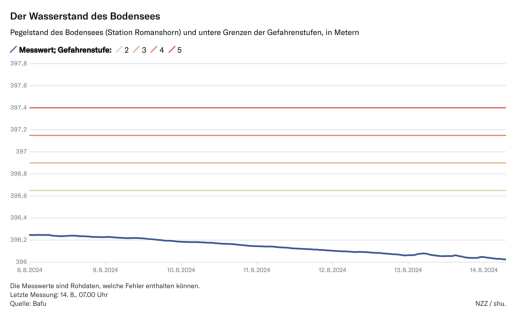

08e996c76bf1a7d4bec453e674f87f98
Line


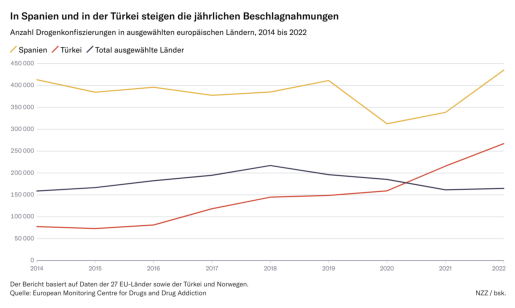

08e996c76bf1a7d4bec453e674f9211e
Line


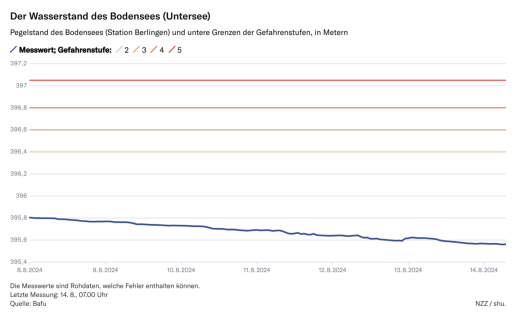

08e996c76bf1a7d4bec453e674f93b65
Line


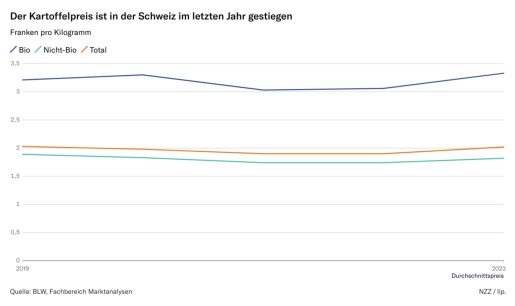

08e996c76bf1a7d4bec453e674faf049
Line


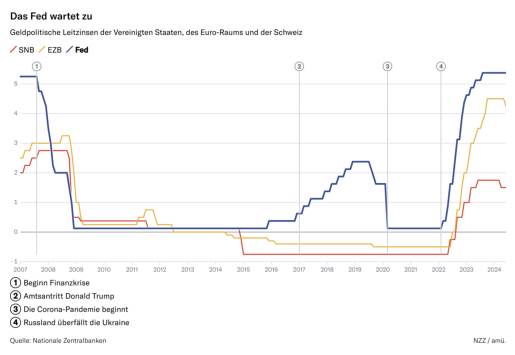

08e996c76bf1a7d4bec453e674fc156b
Line


In [7]:
FIELDS_TO_EXCLUDE = {
    "_rev",
    "department",
    "publication",
    "createdDate",
    "createdBy",
    "updatedDate",
    "updatedBy",
    "deactivateDate",
    "activateDate",
    "thumbnail",
    "data",
    "sources",
}

def clean_json_for_output(json_info):
    """Entfernt unerwünschte Felder aus dem JSON für die Anzeige."""
    return {k: v for k, v in json_info.items() if k not in FIELDS_TO_EXCLUDE}

def extract_data_from_json(json_path):
    """Extrahiert Daten aus einer JSON-Datei und gibt das Dictionary zurück."""
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")
        return None

def chart_type_filter(json_info, chart_type):
    """Filtert nach einem bestimmten Chart-Typ."""
    return json_info.get("options", {}).get("chartType") == chart_type

def has_date_series_option(json_info):
    """Filtert JSONs, die 'dateSeriesOptions' enthalten und nicht leer sind."""
    return bool(json_info.get("options", {}).get("dateSeriesOptions"))

def event_points(json_info):
    return bool(json_info.get("events", {}))

def has_notes(json_info):
    """Gibt True zurück, wenn das Feld 'notes' vorhanden und nicht leer ist."""
    notes = json_info.get("notes", "")
    return bool(notes and isinstance(notes, str) and notes.strip())

def has_highlighted(json_info):
    """Gibt True zurück, wenn highlightDataSeries oder highlightDataRows nicht leer sind."""
    options = json_info.get("options", {})
    series = options.get("highlightDataSeries", [])
    rows = options.get("highlightDataRows", [])
    return bool(series or rows)

def has_prognosis(json_info):
    """Gibt True zurück, wenn ein gültiger Wert für 'prognosisStart' existiert."""
    options = json_info.get("options", {})
    date_opts = options.get("dateSeriesOptions", {})
    prognosis = date_opts.get("prognosisStart")

    return prognosis is not None


def main(filter_lst=None):

    for folder in os.listdir(main_folder):
        folder_path = os.path.join(main_folder, folder)
        if not os.path.isdir(folder_path):
            continue

        json_file_path = os.path.join(folder_path, f"{folder}.json")
        if not os.path.isfile(json_file_path):
            continue

        json_info = extract_data_from_json(json_file_path)
        if json_info is None:
            continue

        if filter_lst and not all(f(json_info) for f in filter_lst):
            continue

        image_path = os.path.join(folder_path, f"{folder}.png")
        if os.path.exists(image_path):
        # Bild laden
            img = mpimg.imread(image_path)
            
            # Bild anzeigen
            plt.imshow(img)
            plt.axis('off')  # Verhindert die Anzeige der Achsen
            plt.show()
        else:
            print(f"Datei unter {image_path} existiert nicht.")

        cleaned = clean_json_for_output(json_info)
        chart_type = cleaned["options"]["chartType"]
        print(cleaned["_id"])
        print(chart_type)
        # print(json.dumps(cleaned, indent=4, ensure_ascii=False))

if __name__ == "__main__":
    filter_functions = [
        lambda json_info: chart_type_filter(json_info, chart_type="Line"),
        # has_date_series_option,
        # has_prognosis,
        # event_points,
        # has_highlighted,
        # has_notes,
    ]

    main(filter_lst=filter_functions)
